<a href="https://colab.research.google.com/github/XanderPatterson/4487-IS-Class-Labs/blob/main/assignment_06_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS 4487 Assignment 6: Data Cleaning with Airbnb Listings

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## 1. Choose a City & Upload Your Dataset

📥 Follow these steps:

1. Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
2. Choose a city you’re interested in.
3. Download the file named: **`listings.csv.gz`** under that city.
4. In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
5. Use the file path `/content/listings.csv.gz` when loading your data.
6. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [7]:
# Read the compressed CSV file directly into a pandas DataFrame
df = pd.read_csv("/content/listings.csv.gz")

# Display the first few rows to confirm it loaded correctly
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,18674,https://www.airbnb.com/rooms/18674,20260624162917,2026-06-25,city scrape,Huge flat for 8 people close to Sagrada Familia,110m2 apartment to rent in Barcelona. Located ...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,71615,...,4.64,4.83,4.38,Spain - National registration number<br />ESFC...,NaN,20,20,0,0,0.37
1,23197,https://www.airbnb.com/rooms/23197,20260624162917,2026-06-25,city scrape,CCIB Forum· Large Balcony · 5 min walk to CCIB,"Beautiful, spacious apartment with large balco...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,90417,...,4.99,4.69,4.71,Spain - National registration number<br />ESFC...,NaN,1,1,0,0,0.53
2,34981,https://www.airbnb.com/rooms/34981,20260624162917,2026-06-25,city scrape,VIDRE HOME PLAZA REAL on LAS RAMBLAS,Spacious apartment for large families or group...,NaN,https://a0.muscache.com/pictures/c4d1723c-e479...,73163,...,4.75,4.65,4.48,Spain - National registration number<br />ESFC...,NaN,2,2,0,0,1.59
3,36763,https://www.airbnb.com/rooms/36763,20260624162917,2026-07-03,previous scrape,In front of the beach,NaN,NaN,https://a0.muscache.com/pictures/airflow/Hosti...,158596,...,4.92,4.92,4.82,NaN,NaN,1,0,1,0,0.60
4,40983,https://www.airbnb.com/rooms/40983,20260624162917,2026-06-25,city scrape,Architect's Loft near Gaudí & Passeig de Gràcia,Stay in a charming architect-designed loft in ...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,177617,...,4.86,4.91,4.52,Barcelona - Regional registration number<br />...,NaN,5,2,3,0,2.46


## 2. Explore Missing Values

### Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

### Do the following:
Explore how complete your dataset is:
- Count the null values of each column
- Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values
- Keep in mind which column(s) are missing too much data, you will delete these in the next step

Top 10 columns with missing values:
                           Missing Count  Missing Percent (%)
neighborhood_overview              15293                100.0
host_since                         15293                100.0
host_verifications                 15293                100.0
host_total_listings_count          15293                100.0
host_thumbnail_url                 15293                100.0
host_response_time                 15293                100.0
host_acceptance_rate               15293                100.0
host_response_rate                 15293                100.0
host_neighbourhood                 15293                100.0
instant_bookable                   15293                100.0


/tmp/ipykernel_2734/1284342513.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df.head(15).index, y=missing_df.head(15)['Missing Percent (%)'], palette='viridis')


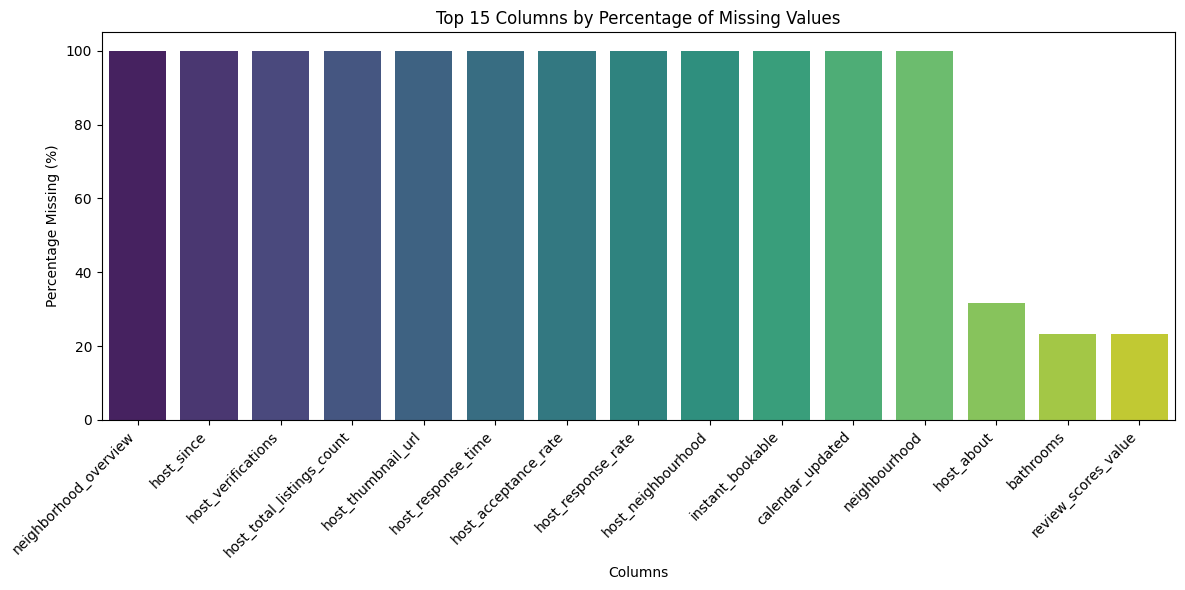

In [8]:
# 1. Count null values and calculate percentages for each column
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Combine into a summary DataFrame and sort by highest missing values
missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Missing Percent (%)': missing_percent})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print("Top 10 columns with missing values:")
print(missing_df.head(10))

# 2. Visualize missing values with a bar chart for top missing columns
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_df.head(15).index, y=missing_df.head(15)['Missing Percent (%)'], palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Top 15 Columns by Percentage of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Percentage Missing (%)')
plt.tight_layout()
plt.show()


### Reflection:
1. What are the top 3 columns with the most missing values?
2. Which ones are likely to create business issues?
3. Which could be safely ignored or dropped?

### ✍️ Your Response: 🔧
1. Any of the top three in the list with 100% would be good options for the top columns.neighborhood_overview              
host_since                
host_verifications  

2. The ones that could create business issues would be price or review score ratings. The normally help the customers decide whether or not to go through with a purchase.

3. The columns that have irrelevant data in the sense that it won't affect it if it isn't there. This is mainly the data that is missing already. Something like license or calendar updated.


## 3. Drop Columns That Aren’t Useful

### Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

### Do the following:
Make a decision:

- Choose 2–4 columns to drop from your dataset
- Document your reasons for each one
- Confirm they're gone with `.head()` or `.info()`

In [9]:
# 1. Define columns to drop (columns with 100% missing values or irrelevant metadata)
columns_to_drop = ['neighborhood_overview', 'host_since', 'host_verifications', 'calendar_updated']

# 2. Drop the columns from the DataFrame
df = df.drop(columns=columns_to_drop)

# 3. Confirm they are removed by checking remaining columns and shape
print("Remaining columns count:", df.shape[1])
print("Confirmed dropped columns are no longer in DataFrame:")
print([col for col in columns_to_drop if col in df.columns])

# Display updated dataset preview
df.head()

Remaining columns count: 86
Confirmed dropped columns are no longer in DataFrame:
[]


,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,18674,https://www.airbnb.com/rooms/18674,20260624162917,2026-06-25,city scrape,Huge flat for 8 people close to Sagrada Familia,110m2 apartment to rent in Barcelona. Located ...,https://a0.muscache.com/pictures/hosting/Hosti...,71615,https://www.airbnb.com/users/show/71615,...,4.64,4.83,4.38,Spain - National registration number<br />ESFC...,NaN,20,20,0,0,0.37
1,23197,https://www.airbnb.com/rooms/23197,20260624162917,2026-06-25,city scrape,CCIB Forum· Large Balcony · 5 min walk to CCIB,"Beautiful, spacious apartment with large balco...",https://a0.muscache.com/pictures/hosting/Hosti...,90417,https://www.airbnb.com/users/show/90417,...,4.99,4.69,4.71,Spain - National registration number<br />ESFC...,NaN,1,1,0,0,0.53
2,34981,https://www.airbnb.com/rooms/34981,20260624162917,2026-06-25,city scrape,VIDRE HOME PLAZA REAL on LAS RAMBLAS,Spacious apartment for large families or group...,https://a0.muscache.com/pictures/c4d1723c-e479...,73163,https://www.airbnb.com/users/show/73163,...,4.75,4.65,4.48,Spain - National registration number<br />ESFC...,NaN,2,2,0,0,1.59
3,36763,https://www.airbnb.com/rooms/36763,20260624162917,2026-07-03,previous scrape,In front of the beach,NaN,https://a0.muscache.com/pictures/airflow/Hosti...,158596,https://www.airbnb.com/users/show/158596,...,4.92,4.92,4.82,NaN,NaN,1,0,1,0,0.60
4,40983,https://www.airbnb.com/rooms/40983,20260624162917,2026-06-25,city scrape,Architect's Loft near Gaudí & Passeig de Gràcia,Stay in a charming architect-designed loft in ...,https://a0.muscache.com/pictures/miso/Hosting-...,177617,https://www.airbnb.com/users/show/177617,...,4.86,4.91,4.52,Barcelona - Regional registration number<br />...,NaN,5,2,3,0,2.46


### Reflection:
1. Which columns did you drop?
2. Why were they not useful from a business perspective?
3. What could go wrong if you left them in?

### ✍️ Your Response: 🔧
1. I dripped neighborhood overiew, the host since, host verification, and calendar updates

2. These columns were ones with 100% of the data missing making them practically useless to use for the data analysis. Things like calendar updates are things that as well don't impact the data.

3. Leaving them in could just take up extra space, slow down the processing speeds, and then just even causing clutter in the reports and visualization.



## 4. Fill or Fix Values in Key Columns

### Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

### Do the following:
- Choose 2 columns with missing values
- Use a strategy to fill or flag those values
  - (e.g., median, “unknown”, forward-fill, or a placeholder)
- Explain what you did and why

In [10]:
# 1. Fill missing numeric review scores with the median value
review_median = df['review_scores_value'].median()
df['review_scores_value'] = df['review_scores_value'].fillna(review_median)

# 2. Fill missing category text with a placeholder "Unknown"
df['neighbourhood'] = df['neighbourhood'].fillna("Unknown")

# 3. Verify that there are no missing values remaining in these two columns
print("Missing values in 'review_scores_value':", df['review_scores_value'].isnull().sum())
print("Missing values in 'neighbourhood':", df['neighbourhood'].isnull().sum())

Missing values in 'review_scores_value': 0
Missing values in 'neighbourhood': 0


### Reflection:
1. What two columns did you clean?
2. What method did you use for each, and why?
3. What risks are there in how you filled the data?

### ✍️ Your Response: 🔧
1. Review scores value and the neighbourhood.

2. For the review scores column I made sure to look at the missing values and used the median rating so that the data stay pretty much even and accurate. This help for the skewness of the distribution. Then for the neighbourhood, I made sure that the data that wasn't known would be marked as unknown so that it can have practically its own separate catigory if needed to help catigorize the data.

3. Review scores with median could make the unrated data appear better or worse then the customers are actually pricing them. The unknown on the neighbourhoods can take out the error codes, but then there are location gaps or missing data in the analysis.


## 5. Convert and Clean Data Types

### Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

### Do the following:
- Identify one column with the wrong data type
- Clean and convert it into a usable format (e.g., from string to number)
- Check your work by summarizing or plotting the cleaned column

Original price data type: object
Sample price values before cleaning:
 0    $409.00
1    $388.00
2    $397.13
3     $43.24
4    $226.13
Name: price, dtype: object

New price data type: float64

Price summary statistics:
count    13355.000000
mean       240.616470
std        339.474553
min          3.500000
25%         89.290000
50%        177.670000
75%        285.500000
max      10542.220000
Name: price, dtype: float64


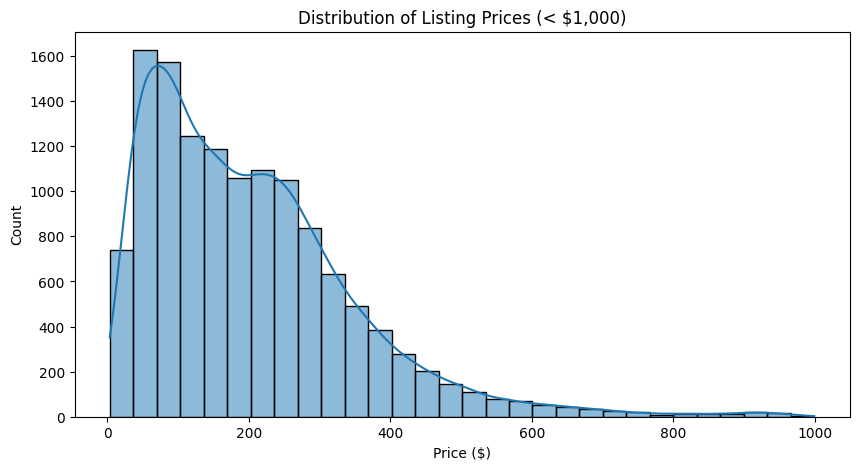

In [11]:
# 1. Inspect the 'price' column data type before cleaning
print("Original price data type:", df['price'].dtype)
print("Sample price values before cleaning:\n", df['price'].head())

# 2. Clean the string: remove '$' signs and ',' commas, then convert to float
df['price'] = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

# 3. Confirm data type conversion and inspect summary statistics
print("\nNew price data type:", df['price'].dtype)
print("\nPrice summary statistics:")
print(df['price'].describe())

# 4. Plot distribution of cleaned prices
plt.figure(figsize=(10, 5))
sns.histplot(df[df['price'] < 1000]['price'], bins=30, kde=True)
plt.title('Distribution of Listing Prices (< $1,000)')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()


### Reflection: :
1. What column did you fix?
2. What cleaning steps did you apply?
3. How does this help prepare the data for later use?

### ✍️ Your Response: 🔧
1. I looked at focusing on price and cleaned that

2. I made the columns into strings in them selves and then added dollar signs and then commas to then be able to change the data to float data.

3. Using this will keep the price at numbers and let you do things like mathematical operations to calculate the average, medians, mean and just do the models in general. This is just better than having it as text.

## 6. Remove Duplicate Records

### Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

### Do the following:
- Check for rows that are exact duplicates
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs
- Remove duplicates if found

In [12]:
# 1. Check for total exact duplicate rows across all columns
exact_duplicates = df.duplicated().sum()
print("Number of exact duplicate rows:", exact_duplicates)

# 2. Check for duplicate IDs (since each listing should have a unique ID)
duplicate_ids = df['id'].duplicated().sum()
print("Number of duplicate listing IDs:", duplicate_ids)

# 3. Drop duplicate rows based on the 'id' column if any exist
if duplicate_ids > 0:
    df = df.drop_duplicates(subset=['id'], keep='first')
    print("Duplicates removed. Updated row count:", len(df))
else:
    print("No duplicate IDs found. Dataset is already unique by listing ID.")

Number of exact duplicate rows: 0
Number of duplicate listing IDs: 0
No duplicate IDs found. Dataset is already unique by listing ID.


### Reflection:
1. Did you find duplicates?
2. How did you decide what to drop or keep?
3. Why are duplicates risky for Airbnb teams?

### ✍️ Your Response: 🔧 🔧
1. No, there wasn't any duplicates and there wan't any duplicate IDs

2. I looked at the duplicate values in things like the id which as supposed to be only unique to one person. Then I just kept the first options and just made sure to get rid of any other additional rows.

3. Having duplicate listings can affect the revenue due to the inflation of it. And then the listing count also shoots up and this will make single properties reflect as many listings and just mislead people in general.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 7**, where you'll perform data transformation techniques.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_6.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```





In [13]:
# Export the cleaned DataFrame to a CSV file
df.to_csv("cleaned_airbnb_data_6.csv", index=False)

print("Cleaned data successfully exported as 'cleaned_airbnb_data_6.csv'!")

Cleaned data successfully exported as 'cleaned_airbnb_data_6.csv'!


## 8. Final Reflection

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### Reflection:
1. Which section of the assignment was the most challenging for you? What made it challenging? Was it the coding or the application of class concepts?
2. Look back at your assignment and discuss a time when you had to drop, fix, or keep a piece of data. Why was it necessary to drop, fix, or keep that specific piece of data? (e.x. dropping a column full of null values because it has no useful information)
3. What’s one way a business team (e.g., hosts, pricing analysts, app administrators) might benefit from the cleaned version of this data?
4. If you had more time, what would you explore or clean further?
5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response: 🔧

1. __  Section 5 I would say was probably the most challenging because much of it were things that I didn't know how to do. It made me combine different strings of data to then clean it up and then convert it to float. I also needed to add commas in and then also dollar signs to the data. I would say that it wasn't the class concepts it was for sure the coding. The coding is't an easy thing to do.
2. __  I had to get rid of colums like neighborhood overview and host since because these were values  that were full of null values and made then not relevent to the analysis I was doing. Taking them out with help with processing time and just clusted data in general.
3. __  Business teams will now have access to more acurate and relevent data. The pricing analyst will be able to get more models and be able to calculate the data and rates across the neighborhoods. This will make it so there isn't missing data and more accurate data.
4. __  I think that with more time I would like to study the outliers for and find out why they are there. For example price, there are listings over 10,000 and I would like to see if this is an error or just a very very nice property. And then taking a look at the dates and making that into actual useful date data.
5. __  This was taking real life data and getting to use it in  things like deciding the best options. I look at how I took messy and out of order data and was able to clean it up and take out irrelevent data. Then I was able to take that data and make models and be able to interpert the models to understand the data better.


## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [ ]:
!jupyter nbconvert --to html "assignment_06_data_cleaning.ipynb"